# CNV benchmark

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
import seaborn.objects as so

custom_params = {"axes.spines.right": False, "axes.spines.top": False}

sns.set_theme(
    context="notebook",
    style="ticks", 
    palette="colorblind",
    font_scale=1.1,
    rc=custom_params
)

# For SVG output
plt.rcParams['svg.fonttype'] = 'none'
figdir = Path("../figures/svg")

In [2]:
base_path = Path("../analysis/cnv_benchmark")

samples = pd.read_csv("../sample_info.tsv", sep="\t") 
samples["Type"] = samples["IsSingleCell"].replace({True: "Single cell", False: "Bulk"})
human_samples = samples.query("Genome == 'Human'")
human_samples

,NGI ID,User ID,IsSingleCell,Kit,Sample,Genome,SampleName,Type
0,P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#01),Single cell
1,P33410_1002,Q_C2_cell_02,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#02),Single cell
2,P33410_1003,Q_D2_cell_03,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#03),Single cell
3,P33410_1004,Q_E2_cell_04,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#04),Single cell
4,P33410_1005,Q_F2_cell_05,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#05),Single cell
5,P33410_1006,Q_G2_cell_06,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#06),Single cell
7,P33410_1008,Q_A3_cell_07,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#07),Single cell
8,P33410_1009,Q_B3_cell_08,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#08),Single cell
9,P33410_1010,Q_C3_cell_09,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#09),Single cell
10,P33410_1011,Q_D3_cell_10,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#10),Single cell


## Agreement

In [3]:
data = []

for tsv in (base_path / "agreement").rglob("*.tsv"):
    binsize, benchtype = tsv.stem.split(".")
    truthset = tsv.parent.stem
    readdepth = tsv.parent.parent.stem
    caller = tsv.parent.parent.parent.stem

    # Skip OGM
    if truthset == "OGM":
        continue

    df = pd.read_csv(tsv, sep="\t", names=["NGI ID", "Agreement"])
    df["Truthset"] = truthset
    df["Caller"] = caller
    df["Binsize"] = binsize
    df["Readdepth"] = readdepth
    df["Benchtype"] = benchtype

    if "penncnv" == caller:
        # Replace names
        df["NGI ID"] = df["NGI ID"].replace(samples.set_index("User ID")["NGI ID"].to_dict())
    data.append(df)

data = pd.concat(data).reset_index(drop=True)
data = data.merge(samples, on="NGI ID")
data = data.query("Genome == 'Human'")
data["Caller_Binsize"] = data[["Caller","Binsize"]].apply(lambda x: f"{x[0]}\n({x[1]})", axis=1)
data["Kit_Readdepth"] = data[["Kit","Readdepth"]].apply(lambda x: f"{x[0]} ({x[1]})", axis=1)
data

/var/folders/9f/8ggsf77s7hx0xcdvhzs8pfjx0t5xky/T/ipykernel_12430/3957516438.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data["Caller_Binsize"] = data[["Caller","Binsize"]].apply(lambda x: f"{x[0]}\n({x[1]})", axis=1)
/var/folders/9f/8ggsf77s7hx0xcdvhzs8pfjx0t5xky/T/ipykernel_12430/3957516438.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data["Kit_Readdepth"] = data[["Kit","Readdepth"]].apply(lambda x: f"{x[0]} ({x[1]})", axis=1)


,NGI ID,Agreement,Truthset,Caller,Binsize,Readdepth,Benchtype,User ID,IsSingleCell,Kit,Sample,Genome,SampleName,Type,Caller_Binsize,Kit_Readdepth
0,P33410_1024,0.930160,PacBio_HiFi,penncnv,none,array,gl,B_H3_10_cells,False,BioSkryb,MM1S cell line,Human,BioSkryb (Bulk),Bulk,penncnv\n(none),BioSkryb (array)
1,P33410_1013,0.917860,PacBio_HiFi,penncnv,none,array,gl,B_A3_cell_01,True,BioSkryb,MM1S cell line,Human,BioSkryb (Cell#01),Single cell,penncnv\n(none),BioSkryb (array)
2,P33410_1015,0.918507,PacBio_HiFi,penncnv,none,array,gl,B_B1_cell_03,True,BioSkryb,MM1S cell line,Human,BioSkryb (Cell#03),Single cell,penncnv\n(none),BioSkryb (array)
3,P33410_1021,0.906133,PacBio_HiFi,penncnv,none,array,gl,B_C3_cell_09,True,BioSkryb,MM1S cell line,Human,BioSkryb (Cell#09),Single cell,penncnv\n(none),BioSkryb (array)
4,P33410_1017,0.912762,PacBio_HiFi,penncnv,none,array,gl,B_B3_cell_05,True,BioSkryb,MM1S cell line,Human,BioSkryb (Cell#05),Single cell,penncnv\n(none),BioSkryb (array)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
571,P33410_1019,0.486622,PacBio_HiFi,ginkgo,1Mb,2M,gl,B_C1_cell_07,True,BioSkryb,MM1S cell line,Human,BioSkryb (Cell#07),Single cell,ginkgo\n(1Mb),BioSkryb (2M)
572,P33410_1020,0.549162,PacBio_HiFi,ginkgo,1Mb,2M,gl,B_C2_cell_08,True,BioSkryb,MM1S cell line,Human,BioSkryb (Cell#08),Single cell,ginkgo\n(1Mb),BioSkryb (2M)
573,P33410_1021,0.890310,PacBio_HiFi,ginkgo,1Mb,2M,gl,B_C3_cell_09,True,BioSkryb,MM1S cell line,Human,BioSkryb (Cell#09),Single cell,ginkgo\n(1Mb),BioSkryb (2M)
574,P33410_1022,0.887892,PacBio_HiFi,ginkgo,1Mb,2M,gl,B_C4_cell_10,True,BioSkryb,MM1S cell line,Human,BioSkryb (Cell#10),Single cell,ginkgo\n(1Mb),BioSkryb (2M)


In [4]:
def plot_agreement(d, ylabel, filename=None):
    hue_order = sorted(d["Kit_Readdepth"].unique())
    order = [
        'copykit\n(110kb)',
        'copykit\n(220kb)',
        'copykit\n(500kb)',
        'copykit\n(1Mb)',
        'ginkgo\n(1Mb)'
    ]
    palette = sns.color_palette("Blues", n_colors=2) + sns.color_palette("Oranges", n_colors=3)
    g = sns.catplot(
        data=d, 
        kind="swarm",
        x="Caller_Binsize",
        order=order, 
        y="Agreement", 
        hue="Kit_Readdepth",
        hue_order=hue_order,
        palette=palette,
        aspect=3, 
        s=15,
        height=2.5,
        dodge=True,
        width=0.3,
    )

    g.map_dataframe(
        sns.violinplot,
        data=d, 
        x="Caller_Binsize",
        y="Agreement",
        inner="quart", 
        fill=None, 
        hue="Kit_Readdepth",
        hue_order=hue_order,
        palette="dark:k", 
        dodge=True,
        density_norm="width",
        zorder=-1,
        alpha=0.9,
        cut=0.5,
    )

    g.set(ylabel=ylabel, xlabel="")

    for ax in g.axes.flat:
        ax.set_ylim(bottom=0)
        ax.grid(True, axis='y', alpha=0.5)
    
    if filename:
        plt.savefig(filename, bbox_inches="tight")

### Copy number agreement

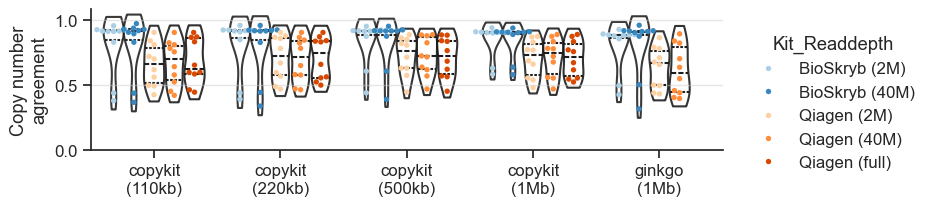

In [5]:
d = data.query("IsSingleCell == True & Benchtype == 'cn' & Binsize != 'none'")
plot_agreement(d, "Copy number\nagreement", figdir / "cnv_benchmark_singlecell_cn_agreement.svg")

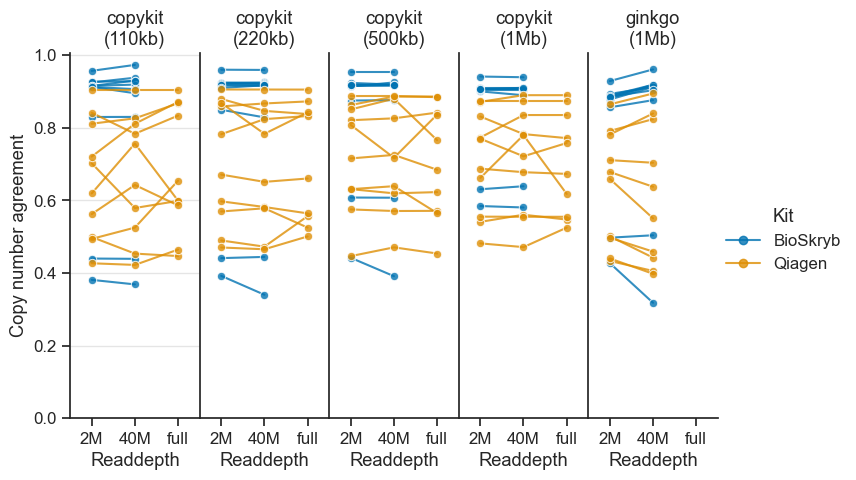

In [6]:
d = data.query("IsSingleCell == True & Benchtype == 'cn' & Binsize != 'none' & Truthset == 'PacBio_HiFi'")
d = d.sort_values(["Kit_Readdepth"])

hue_order = sorted(d["Kit_Readdepth"].unique())
d["Range"] = d["Kit_Readdepth"].map(dict(zip(hue_order, range(len(hue_order)))))
col_order = [
    'copykit\n(110kb)',
    'copykit\n(220kb)',
    'copykit\n(500kb)',
    'copykit\n(1Mb)',
    'ginkgo\n(1Mb)'
]
palette = sns.color_palette("Blues", n_colors=2) + sns.color_palette("Oranges", n_colors=3)
g = sns.relplot(
    data=d, 
    kind="line",
    x="Readdepth",
    col_order=col_order, 
    y="Agreement", 
    hue="Kit",
    style="Kit",
    dashes=False,
    col="Caller_Binsize",
    palette="colorblind",
    units="SampleName",
    aspect=0.3,
    markers=["o", "o"],
    alpha=0.8,
    height=5,
    estimator=None)

g.set(ylabel="Copy number agreement")
g.set_titles(col_template="{col_name}")
for ax in g.axes.flat:
    ax.set_ylim(bottom=0)
    ax.set_xlim(left=-0.5, right=2.5)
    ax.grid(True, axis='y', alpha=0.5)
    if not ax.get_subplotspec().is_first_col():
        ax.get_yaxis().set_visible(False)


g.figure.subplots_adjust(wspace=0)
        

plt.savefig(figdir / "cnv_benchmark_singlecell_cn_agreement_pacbio.svg", bbox_inches="tight", transparent=True)

In [7]:
d.groupby(["Kit", "Readdepth", "Caller", "Binsize"])["Agreement"].median().reset_index()\
 .pivot(index=["Readdepth", "Caller", "Binsize"], columns="Kit", values="Agreement").round(2).reset_index()

Kit,Readdepth,Caller,Binsize,BioSkryb,Qiagen
0,2M,copykit,110kb,0.91,0.66
1,2M,copykit,1Mb,0.91,0.73
2,2M,copykit,220kb,0.92,0.73
3,2M,copykit,500kb,0.92,0.76
4,2M,ginkgo,1Mb,0.88,0.67
5,40M,copykit,110kb,0.91,0.70
6,40M,copykit,1Mb,0.91,0.75
7,40M,copykit,220kb,0.92,0.72
8,40M,copykit,500kb,0.92,0.72
9,40M,ginkgo,1Mb,0.91,0.59


### Bulk samples

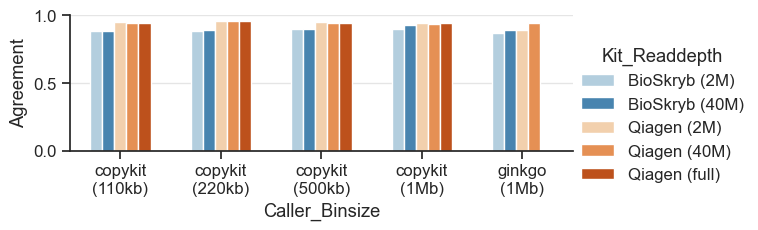

In [8]:
d = data.query("IsSingleCell == False & Benchtype == 'cn' & Binsize != 'none'")

hue_order = sorted(d["Kit_Readdepth"].unique())
order = [
    'copykit\n(110kb)',
    'copykit\n(220kb)',
    'copykit\n(500kb)',
    'copykit\n(1Mb)',
    'ginkgo\n(1Mb)'
]
palette = sns.color_palette("Blues", n_colors=2) + sns.color_palette("Oranges", n_colors=3)
g = sns.catplot(
    data=d, 
    kind="bar",
    x="Caller_Binsize",
    order=order, 
    y="Agreement", 
    hue="Kit_Readdepth",
    hue_order=hue_order,
    palette=palette,
    aspect=2.5, 
    height=2.5,
    dodge=True,
    width=0.6,
)
#g.set(ylim=(0.8, 1))
# Add grid
for ax in g.axes.flat:
    ax.grid(True, axis='y', alpha=0.5)

In [9]:
data.query("Benchtype == 'cn' & Binsize != 'none'")\
    .groupby(["Kit", "IsSingleCell"]).agg(
    mean_agreement=("Agreement", "mean"),
    std_agreement=("Agreement", "std"),
).reset_index()

,Kit,IsSingleCell,mean_agreement,std_agreement
0,BioSkryb,False,0.893137,0.016110
1,BioSkryb,True,0.823625,0.182958
2,Qiagen,False,0.944018,0.015858
3,Qiagen,True,0.689899,0.155500


### SNP array

/Users/pontus.hojer/miniconda3/envs/aviti/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 18.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


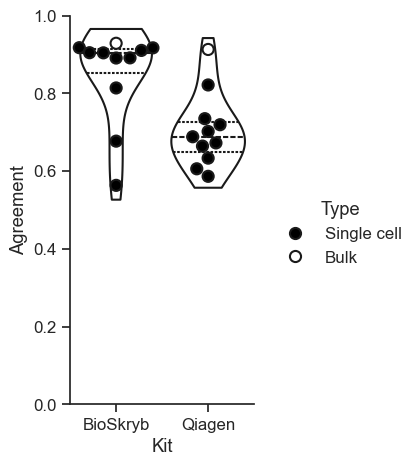

In [10]:
d = data.query("Benchtype == 'cn' & Caller == 'penncnv'").copy()
g = sns.catplot(
    data=d,
    kind="swarm",
    x="Kit",
    y="Agreement",
    hue="Type",
    hue_order=["Single cell", "Bulk"],
    edgecolor="k",
    linewidth=1.5,
    palette=["black", "white"],
    height=4.8,
    aspect=0.6,
    width=0.3,
    size=8
)
g.map_dataframe(
    sns.violinplot,
    data=d.query("IsSingleCell == True"),
    x="Kit",
    y="Agreement",
    fill=None,
    color="k",
    inner="quart",
    cut=0.5,
    )
g.set(ylim=(0, 1))

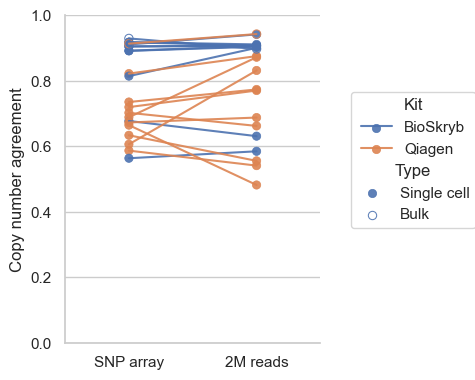

In [11]:
readdepth = ["2M", "array"]
caller = ["penncnv", "copykit"]
binsize = ["none", "1Mb"]
d = data.query(
    "Benchtype == 'cn' & Readdepth in @readdepth & Caller in @caller\
    & Binsize in @binsize & Truthset == 'PacBio_HiFi'").copy()
d["Caller_Binsize"] = d["Caller"] + "\n(" + d["Binsize"] + ")"

d["data"] = d["Readdepth"].replace({
    "2M": "2M reads",
    "array": "SNP array"
})
d = d.sort_values("Type", ascending=False)
fig = plt.figure(figsize=(3.5,4))
p = (
    so.Plot(d, x="data", y="Agreement", color="Kit", group="SampleName")
    .add(so.Dot(alpha=0.9), fill="Type")
    .add(so.Path(alpha=0.9))
    
    .label(y="Copy number agreement", x="")
    .limit(y=(0, 1))
    .scale(
        color=so.Nominal(order=["BioSkryb", "Qiagen"]),
        x=so.Nominal(order=["SNP array", "2M reads"]),
    )
    .layout(engine="tight")
    .theme(sns.axes_style("whitegrid") | sns.plotting_context("notebook"))
    .theme(custom_params)
    .on(fig)
    .save(figdir / "cnv_benchmark_array_vs_2M_pacbio.svg", dpi=300, bbox_inches="tight", transparent=True)
)
